In [2]:
import polars as pl

from pathlib import Path

In [6]:
FILE_PATH = Path('../Pandas/utils/03-HowLoadandSaveDatasets/dataset_parquet.parquet')
df = pl.read_parquet(FILE_PATH)
df.head()

customer_id,surname,credit_score,geography,gender,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,exited,complain,satisfaction_score,card_type,point_earned
i64,str,i64,str,str,i64,i64,f64,i64,i64,i64,f64,i64,i64,i64,str,i64
15634602,"""Hargrave""",619,"""France""","""Female""",42,2,0.0,1,1,1,101348.88,1,1,2,"""DIAMOND""",464
15647311,"""Hill""",608,"""Spain""","""Female""",41,1,83807.86,1,0,1,112542.58,0,1,3,"""DIAMOND""",456
15619304,"""Onio""",502,"""France""","""Female""",42,8,159660.8,3,1,0,113931.57,1,1,3,"""DIAMOND""",377
15701354,"""Boni""",699,"""France""","""Female""",39,1,0.0,2,0,0,93826.63,0,0,5,"""GOLD""",350
15737888,"""Mitchell""",850,"""Spain""","""Female""",43,2,125510.82,1,1,1,79084.1,0,0,5,"""GOLD""",425


# Filter
No polars para fazer filtros podemos utilizar o método `.filter()`

In [7]:
df.filter(pl.col('credit_score') > 600).head()

customer_id,surname,credit_score,geography,gender,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,exited,complain,satisfaction_score,card_type,point_earned
i64,str,i64,str,str,i64,i64,f64,i64,i64,i64,f64,i64,i64,i64,str,i64
15634602,"""Hargrave""",619,"""France""","""Female""",42,2,0.0,1,1,1,101348.88,1,1,2,"""DIAMOND""",464
15647311,"""Hill""",608,"""Spain""","""Female""",41,1,83807.86,1,0,1,112542.58,0,1,3,"""DIAMOND""",456
15701354,"""Boni""",699,"""France""","""Female""",39,1,0.0,2,0,0,93826.63,0,0,5,"""GOLD""",350
15737888,"""Mitchell""",850,"""Spain""","""Female""",43,2,125510.82,1,1,1,79084.1,0,0,5,"""GOLD""",425
15574012,"""Chu""",645,"""Spain""","""Male""",44,8,113755.78,2,1,0,149756.71,1,1,5,"""DIAMOND""",484


Também é possivel adicionar filtros compostos usando `& (e)`, `| (ou)` e `~ (negação)`.

In [9]:
# utilizando E (&)
mask = (
    (pl.col('credit_score') > 600) &
    (pl.col('geography') == 'Spain')
)
df.filter(mask).head()

customer_id,surname,credit_score,geography,gender,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,exited,complain,satisfaction_score,card_type,point_earned
i64,str,i64,str,str,i64,i64,f64,i64,i64,i64,f64,i64,i64,i64,str,i64
15647311,"""Hill""",608,"""Spain""","""Female""",41,1,83807.86,1,0,1,112542.58,0,1,3,"""DIAMOND""",456
15737888,"""Mitchell""",850,"""Spain""","""Female""",43,2,125510.82,1,1,1,79084.1,0,0,5,"""GOLD""",425
15574012,"""Chu""",645,"""Spain""","""Male""",44,8,113755.78,2,1,0,149756.71,1,1,5,"""DIAMOND""",484
15600882,"""Scott""",635,"""Spain""","""Female""",35,7,0.0,2,1,1,65951.65,0,0,2,"""GOLD""",318
15597945,"""Dellucci""",636,"""Spain""","""Female""",32,8,0.0,2,1,0,138555.46,0,0,2,"""DIAMOND""",336


In [10]:
# utilizando OU (|)
mask = (
    (pl.col('credit_score') > 600) |
    (pl.col('geography') == 'Spain')
)
df.filter(mask).head()

customer_id,surname,credit_score,geography,gender,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,exited,complain,satisfaction_score,card_type,point_earned
i64,str,i64,str,str,i64,i64,f64,i64,i64,i64,f64,i64,i64,i64,str,i64
15634602,"""Hargrave""",619,"""France""","""Female""",42,2,0.0,1,1,1,101348.88,1,1,2,"""DIAMOND""",464
15647311,"""Hill""",608,"""Spain""","""Female""",41,1,83807.86,1,0,1,112542.58,0,1,3,"""DIAMOND""",456
15701354,"""Boni""",699,"""France""","""Female""",39,1,0.0,2,0,0,93826.63,0,0,5,"""GOLD""",350
15737888,"""Mitchell""",850,"""Spain""","""Female""",43,2,125510.82,1,1,1,79084.1,0,0,5,"""GOLD""",425
15574012,"""Chu""",645,"""Spain""","""Male""",44,8,113755.78,2,1,0,149756.71,1,1,5,"""DIAMOND""",484


In [16]:
print(df['card_type'].value_counts())
print('-' * 30)
print(df['card_type'].value_counts(normalize=True))
print('-' * 30)
print(df['card_type'].value_counts(name='qtde'))

shape: (4, 2)
┌───────────┬───────┐
│ card_type ┆ count │
│ ---       ┆ ---   │
│ str       ┆ u32   │
╞═══════════╪═══════╡
│ PLATINUM  ┆ 2495  │
│ DIAMOND   ┆ 2507  │
│ GOLD      ┆ 2502  │
│ SILVER    ┆ 2496  │
└───────────┴───────┘
------------------------------
shape: (4, 2)
┌───────────┬────────────┐
│ card_type ┆ proportion │
│ ---       ┆ ---        │
│ str       ┆ f64        │
╞═══════════╪════════════╡
│ PLATINUM  ┆ 0.2495     │
│ SILVER    ┆ 0.2496     │
│ GOLD      ┆ 0.2502     │
│ DIAMOND   ┆ 0.2507     │
└───────────┴────────────┘
------------------------------
shape: (4, 2)
┌───────────┬──────┐
│ card_type ┆ qtde │
│ ---       ┆ ---  │
│ str       ┆ u32  │
╞═══════════╪══════╡
│ GOLD      ┆ 2502 │
│ DIAMOND   ┆ 2507 │
│ PLATINUM  ┆ 2495 │
│ SILVER    ┆ 2496 │
└───────────┴──────┘


In [18]:
# utilizando o isin
mask = pl.col('card_type').is_in(['DIAMOND', 'GOLD'])
df.filter(mask).head()

customer_id,surname,credit_score,geography,gender,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,exited,complain,satisfaction_score,card_type,point_earned
i64,str,i64,str,str,i64,i64,f64,i64,i64,i64,f64,i64,i64,i64,str,i64
15634602,"""Hargrave""",619,"""France""","""Female""",42,2,0.0,1,1,1,101348.88,1,1,2,"""DIAMOND""",464
15647311,"""Hill""",608,"""Spain""","""Female""",41,1,83807.86,1,0,1,112542.58,0,1,3,"""DIAMOND""",456
15619304,"""Onio""",502,"""France""","""Female""",42,8,159660.8,3,1,0,113931.57,1,1,3,"""DIAMOND""",377
15701354,"""Boni""",699,"""France""","""Female""",39,1,0.0,2,0,0,93826.63,0,0,5,"""GOLD""",350
15737888,"""Mitchell""",850,"""Spain""","""Female""",43,2,125510.82,1,1,1,79084.1,0,0,5,"""GOLD""",425


In [21]:
# utilizando a negação (~)
mask = pl.col('card_type').is_in(['DIAMOND', 'GOLD'])
df.filter(~mask).head()

customer_id,surname,credit_score,geography,gender,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,exited,complain,satisfaction_score,card_type,point_earned
i64,str,i64,str,str,i64,i64,f64,i64,i64,i64,f64,i64,i64,i64,str,i64
15592531,"""Bartlett""",822,"""France""","""Male""",50,7,0.0,2,1,1,10062.8,0,0,2,"""SILVER""",206
15632264,"""Kay""",476,"""France""","""Female""",34,10,0.0,2,1,0,26260.98,0,0,3,"""SILVER""",119
15691483,"""Chin""",549,"""France""","""Female""",25,5,0.0,2,0,0,190857.79,0,0,3,"""PLATINUM""",549
15737452,"""Romeo""",653,"""Germany""","""Male""",58,1,132602.88,1,1,0,5097.67,1,0,2,"""SILVER""",163
15788218,"""Henderson""",549,"""Spain""","""Female""",24,9,0.0,2,1,1,14406.41,0,0,3,"""SILVER""",544


In [23]:
# podemos utilizar o between
# closed: {‘both’, ‘left’, ‘right’, ‘none’}
mask = pl.col('credit_score').is_between(200, 600, closed='both')
df.select(mask)

credit_score
bool
false
false
true
false
false
…
false
true
false


In [24]:
# Podemos encadear vários filtros
filter_1 = pl.col('point_earned') > 200
filter_2 = pl.col('estimated_salary') < 10_000
filter_3 = pl.col('credit_score').is_between(200, 600, closed='both')
filter_4 = pl.col('card_type').is_in(['DIAMOND', 'GOLD'])

all_filters = (filter_1 & filter_2 & filter_3 & filter_4)

df.filter(all_filters).head()

customer_id,surname,credit_score,geography,gender,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,exited,complain,satisfaction_score,card_type,point_earned
i64,str,i64,str,str,i64,i64,f64,i64,i64,i64,f64,i64,i64,i64,str,i64
15671137,"""MacDonald""",549,"""France""","""Female""",52,1,0.0,1,0,1,8636.05,1,1,4,"""DIAMOND""",485
15640905,"""Vasin""",579,"""Spain""","""Female""",35,1,129490.36,2,0,1,8590.83,1,1,4,"""GOLD""",247
15794413,"""Harris""",416,"""France""","""Male""",32,0,0.0,2,0,1,878.87,0,0,5,"""GOLD""",884
15651022,"""Yost""",480,"""Germany""","""Male""",44,10,129608.57,1,1,0,5472.7,1,1,1,"""GOLD""",775
15684548,"""Demidov""",556,"""Spain""","""Male""",38,8,0.0,2,0,0,417.41,1,1,3,"""GOLD""",632


# `.top_k()` e `.bottom_k()`
- `.top_k()`: Pega os *n* maiores;
- `.bottom_k()`: Pega os *n* menores

In [26]:
# os 5 com maior age
df.top_k(5, by='age')

customer_id,surname,credit_score,geography,gender,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,exited,complain,satisfaction_score,card_type,point_earned
i64,str,i64,str,str,i64,i64,f64,i64,i64,i64,f64,i64,i64,i64,str,i64
15764927,"""Rogova""",753,"""France""","""Male""",92,3,121513.31,1,0,1,195563.99,0,0,3,"""PLATINUM""",307
15660878,"""T'ien""",705,"""France""","""Male""",92,1,126076.24,2,1,1,34436.83,0,0,5,"""SILVER""",772
15813303,"""Rearick""",513,"""Spain""","""Male""",88,10,0.0,2,1,1,52952.24,0,0,1,"""PLATINUM""",627
15578006,"""Yao""",787,"""France""","""Female""",85,10,0.0,2,1,1,116537.96,0,0,2,"""GOLD""",542
15798024,"""Lori""",537,"""Germany""","""Male""",84,8,92242.34,1,1,1,186235.98,0,0,3,"""SILVER""",768


In [28]:
# os 5 com menor age
df.bottom_k(5, by='age')

customer_id,surname,credit_score,geography,gender,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,exited,complain,satisfaction_score,card_type,point_earned
i64,str,i64,str,str,i64,i64,f64,i64,i64,i64,f64,i64,i64,i64,str,i64
15757821,"""Burgess""",771,"""Spain""","""Male""",18,1,0.0,2,0,0,41542.95,0,0,1,"""GOLD""",371
15569178,"""Kharlamov""",570,"""France""","""Female""",18,4,82767.42,1,1,0,71811.9,0,0,5,"""SILVER""",507
15795519,"""Vasiliev""",716,"""Germany""","""Female""",18,3,128743.8,1,0,0,197322.13,0,0,5,"""GOLD""",243
15621893,"""Bellucci""",727,"""France""","""Male""",18,4,133550.67,1,1,1,46941.41,0,0,4,"""PLATINUM""",864
15758372,"""Wallace""",674,"""France""","""Male""",18,7,0.0,2,1,1,55753.12,1,1,5,"""DIAMOND""",603


# Valores Faltantes (NA's)

In [30]:
df = pl.DataFrame({
    'col_a': [1, 2, None, 4, 5],
    'col_b': ['x', None, 'z', None, 'y'],
    'col_c': [1, 2, 3, 4, None],
})
print(df)

shape: (5, 3)
┌───────┬───────┬───────┐
│ col_a ┆ col_b ┆ col_c │
│ ---   ┆ ---   ┆ ---   │
│ i64   ┆ str   ┆ i64   │
╞═══════╪═══════╪═══════╡
│ 1     ┆ x     ┆ 1     │
│ 2     ┆ null  ┆ 2     │
│ null  ┆ z     ┆ 3     │
│ 4     ┆ null  ┆ 4     │
│ 5     ┆ y     ┆ null  │
└───────┴───────┴───────┘


In [32]:
# Filtrando quem é NAN
df.filter(pl.col('col_b').is_null())

col_a,col_b,col_c
i64,str,i64
2,null,2
4,null,4


In [33]:
df.null_count()

col_a,col_b,col_c
u32,u32,u32
1,2,1


In [36]:
df.select(pl.all().is_null())

col_a,col_b,col_c
bool,bool,bool
false,false,false
false,true,false
true,false,false
false,true,false
false,false,true


In [38]:
# Filtrando quem não é NAN
df.filter(pl.col('col_a').is_not_null())

col_a,col_b,col_c
i64,str,i64
1,"""x""",1
2,null,2
4,null,4
5,"""y""",null


In [40]:
# podemos remover os nans com dropna()
df.drop_nulls(subset='col_b')

col_a,col_b,col_c
i64,str,i64
1,"""x""",1
null,"""z""",3
5,"""y""",null


# Linhas Duplicadas

In [41]:
df = pl.DataFrame({
    "A": [1, 1, 2, 3, 3, 3],
    "B": ["x", "x", "y", "z", "z", "z"],
})
df

A,B
i64,str
1,"""x"""
1,"""x"""
2,"""y"""
3,"""z"""
3,"""z"""
3,"""z"""


In [43]:
# Mostrando todas as linhas duplicadas
df.is_duplicated()

""
bool
true
true
false
true
true
true


In [54]:
# remove quem não é duplicado
df.filter(df.is_duplicated())

A,B
i64,str
1,"""x"""
1,"""x"""
3,"""z"""
3,"""z"""
3,"""z"""


In [55]:
# remove todas duplicadas
df.filter(~df.is_duplicated())

A,B
i64,str
2,"""y"""


In [58]:
# keep : {'first', 'last', 'any', 'none'}
#     Which of the duplicate rows to keep.
# 
#     * 'any': Does not give any guarantee of which row is kept.
#              This allows more optimizations.
#     * 'none': Don't keep duplicate rows.
#     * 'first': Keep first unique row.
#     * 'last': Keep last unique row.

# é equivalente ao df.drop_duiplicates()
df.unique(keep='last', maintain_order=True)

A,B
i64,str
1,"""x"""
2,"""y"""
3,"""z"""


# Filtrando por tipo de coluna
Podemos querer filtras apenas colunas do mesmo tipo, podemos fazer isso assim:
```python
pl.selectors.numeric()
pl.selectors.string()
```

In [59]:
df = pl.read_parquet(FILE_PATH)

In [66]:
# numéricas
df.select(pl.selectors.numeric()).head()

customer_id,credit_score,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,exited,complain,satisfaction_score,point_earned
i64,i64,i64,i64,f64,i64,i64,i64,f64,i64,i64,i64,i64
15634602,619,42,2,0.0,1,1,1,101348.88,1,1,2,464
15647311,608,41,1,83807.86,1,0,1,112542.58,0,1,3,456
15619304,502,42,8,159660.8,3,1,0,113931.57,1,1,3,377
15701354,699,39,1,0.0,2,0,0,93826.63,0,0,5,350
15737888,850,43,2,125510.82,1,1,1,79084.1,0,0,5,425


In [67]:
# string
df.select(pl.selectors.string()).head()

surname,geography,gender,card_type
str,str,str,str
"""Hargrave""","""France""","""Female""","""DIAMOND"""
"""Hill""","""Spain""","""Female""","""DIAMOND"""
"""Onio""","""France""","""Female""","""DIAMOND"""
"""Boni""","""France""","""Female""","""GOLD"""
"""Mitchell""","""Spain""","""Female""","""GOLD"""


# Tempo de execução

In [68]:
import numpy as np

N = 100_000_000  # 100 milhões
data = {
    'cat': np.random.choice(['foo', 'bar', 'baz'], size=(N)),
    'num': np.random.rand(N)
}
df_big = pl.DataFrame(data)

In [69]:
print(df_big.head())

shape: (5, 2)
┌─────┬──────────┐
│ cat ┆ num      │
│ --- ┆ ---      │
│ str ┆ f64      │
╞═════╪══════════╡
│ bar ┆ 0.065064 │
│ baz ┆ 0.495499 │
│ baz ┆ 0.713337 │
│ baz ┆ 0.55763  │
│ bar ┆ 0.796555 │
└─────┴──────────┘


In [70]:
# tempo de filtro
mask = (
    (pl.col('cat') == 'bar') &
    (pl.col('num') < 0.5)
)
%timeit df_big.filter(mask)

942 ms ± 190 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


Execução feita no `pandas`:
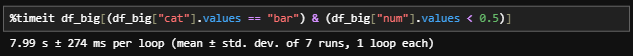

Em comparação com o `pandas` o `polars` foi **8.5x** mais rápido.